# Imports

In [1]:
%pip install imbalanced-learn
%pip install mlflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd


In [3]:

from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from sklearn.naive_bayes import GaussianNB
from imblearn.under_sampling import TomekLinks
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
import mlflow
import mlflow.sklearn
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,

    precision_score, recall_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt


In [4]:
import os
from pathlib import Path
ROOT = Path(os.getcwd())
while not (ROOT / 'src').exists():
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'youtube'

In [5]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('__file__').resolve().parents[3] / 'src'))
from who_will_viral.models.mlflow_utilities import setup_mlflow, run_experiment
print(os.getcwd())
setup_mlflow()

/Users/zeyaddaowd/Desktop/DS/who-will-viral/src/who_will_viral/models
/Users/zeyaddaowd/Desktop/DS/who-will-viral/src/who_will_viral/models


/opt/anaconda3/envs/geo_env/lib/python3.11/site-packages/mlflow/tracking/_tracking_service/utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


# Load Datasets

In [6]:
training_dataset = pd.read_csv(f"{DATA}/scaled_train.csv")
test_dataset = pd.read_csv(f"{DATA}/scaled_test.csv")
val_dataset = pd.read_csv(f"{DATA}/scaled_val.csv")

In [7]:
X_train, y_train = training_dataset.drop('is_trending', axis=1), training_dataset['is_trending']
X_test, y_test = test_dataset.drop('is_trending', axis=1), test_dataset['is_trending']
X_val, y_val = val_dataset.drop('is_trending', axis=1), val_dataset['is_trending']

testing for oriignal distribution
Confusion Matrix: TN=29609, FP=77, FN=597, TP=5843
  
baseline
  accuracy: 0.9813
  f1: 0.9671
  precision: 0.9870
  recall: 0.9073
  roc_auc: 0.9941
  Wasted_Resources_False_Positive: 0.0130
  Missed_Trending_Videos: 0.0927

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     29686
           1       0.99      0.91      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.95      0.97     36126
weighted avg       0.98      0.98      0.98     36126



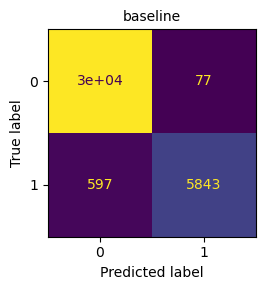

2026/04/12 13:27:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:27:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99     29686\n           1       0.99      0.91      0.95      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.98      0.95      0.97     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [8]:
def baseline(run_name, X_train, y_train, X_val, y_val, weighted = False):
    rf = RandomForestClassifier(class_weight="balanced" if weighted else None)
    run_experiment(run_name, rf, X_train, y_train, X_val, y_val)
    y_pred_val = rf.predict(X_val)
    return classification_report(y_val, y_pred_val)
print("testing for oriignal distribution")
(baseline("baseline", X_train, y_train, X_val, y_val))

testing for orignal distribution + class weights
Confusion Matrix: TN=29621, FP=65, FN=615, TP=5825
  
baseline_weighted
  accuracy: 0.9812
  f1: 0.9668
  precision: 0.9890
  recall: 0.9045
  roc_auc: 0.9948
  Wasted_Resources_False_Positive: 0.0110
  Missed_Trending_Videos: 0.0955

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     29686
           1       0.99      0.90      0.94      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.95      0.97     36126
weighted avg       0.98      0.98      0.98     36126



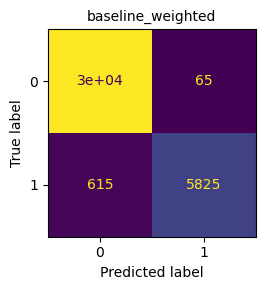

2026/04/12 13:28:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:28:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99     29686\n           1       0.99      0.90      0.94      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.98      0.95      0.97     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [9]:
print("testing for orignal distribution + class weights")
(baseline("baseline_weighted", X_train, y_train, X_val, y_val, weighted = True))

In [10]:
## Oversampling
def get_class_ratio(y):
    return (1 - sum(y) / len(y)) / (sum(y) / len(y))
print("Original training class ratio:", get_class_ratio(y_train))
oversample = RandomOverSampler(sampling_strategy='minority')
X_over, y_over = oversample.fit_resample(X_train, y_train)
print("Oversampled class distribution:", get_class_ratio(y_over))

undersample = RandomUnderSampler(sampling_strategy='majority')
X_under, y_under = undersample.fit_resample(X_train, y_train)
print("Undersampled class distribution:", get_class_ratio(y_under))

tl = TomekLinks(sampling_strategy='majority')
X_tl, y_tl = tl.fit_resample(X_train, y_train)
print("Undersampled (tomek link) class distribution:", get_class_ratio(y_tl))

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)
print("Smote class distribution:", get_class_ratio(y_smote))

Original training class ratio: 4.609181719372703
Oversampled class distribution: 1.0
Undersampled class distribution: 1.0
Undersampled (tomek link) class distribution: 4.579628383624036
Smote class distribution: 1.0


testing for oversampled data
Confusion Matrix: TN=29554, FP=132, FN=529, TP=5911
  
baseline_oversampled
  accuracy: 0.9817
  f1: 0.9680
  precision: 0.9782
  recall: 0.9179
  roc_auc: 0.9953
  Wasted_Resources_False_Positive: 0.0218
  Missed_Trending_Videos: 0.0821

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     29686
           1       0.98      0.92      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.96      0.97     36126
weighted avg       0.98      0.98      0.98     36126



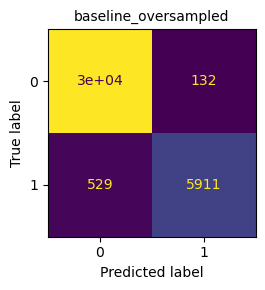

2026/04/12 13:28:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:28:40 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99     29686\n           1       0.98      0.92      0.95      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.98      0.96      0.97     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [11]:
print("testing for oversampled data")
(baseline("baseline_oversampled", X_over, y_over, X_val, y_val))


testing for undersampled (tl) data
Confusion Matrix: TN=29600, FP=86, FN=572, TP=5868
  
baseline_undersampled (tl)
  accuracy: 0.9818
  f1: 0.9680
  precision: 0.9856
  recall: 0.9112
  roc_auc: 0.9946
  Wasted_Resources_False_Positive: 0.0144
  Missed_Trending_Videos: 0.0888

              precision    recall  f1-score   support

           0       0.98      1.00      0.99     29686
           1       0.99      0.91      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.98      0.95      0.97     36126
weighted avg       0.98      0.98      0.98     36126



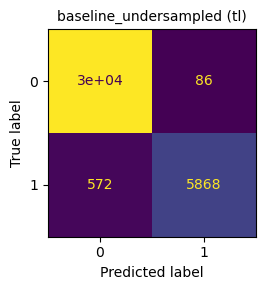

2026/04/12 13:29:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:29:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.98      1.00      0.99     29686\n           1       0.99      0.91      0.95      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.98      0.95      0.97     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [12]:
print("testing for undersampled (tl) data")
(baseline("baseline_undersampled (tl)", X_tl, y_tl, X_val, y_val))


testing for undersampled data
Confusion Matrix: TN=29129, FP=557, FN=320, TP=6120
  
baseline_undersampled
  accuracy: 0.9757
  f1: 0.9592
  precision: 0.9166
  recall: 0.9503
  roc_auc: 0.9952
  Wasted_Resources_False_Positive: 0.0834
  Missed_Trending_Videos: 0.0497

              precision    recall  f1-score   support

           0       0.99      0.98      0.99     29686
           1       0.92      0.95      0.93      6440

    accuracy                           0.98     36126
   macro avg       0.95      0.97      0.96     36126
weighted avg       0.98      0.98      0.98     36126



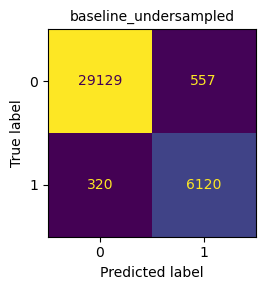

2026/04/12 13:29:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:29:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.99      0.98      0.99     29686\n           1       0.92      0.95      0.93      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.95      0.97      0.96     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [13]:
print("testing for undersampled data")
(baseline("baseline_undersampled", X_under, y_under, X_val, y_val))


testing after applying smote
Confusion Matrix: TN=29419, FP=267, FN=420, TP=6020
  
baseline_smote
  accuracy: 0.9810
  f1: 0.9672
  precision: 0.9575
  recall: 0.9348
  roc_auc: 0.9955
  Wasted_Resources_False_Positive: 0.0425
  Missed_Trending_Videos: 0.0652

              precision    recall  f1-score   support

           0       0.99      0.99      0.99     29686
           1       0.96      0.93      0.95      6440

    accuracy                           0.98     36126
   macro avg       0.97      0.96      0.97     36126
weighted avg       0.98      0.98      0.98     36126



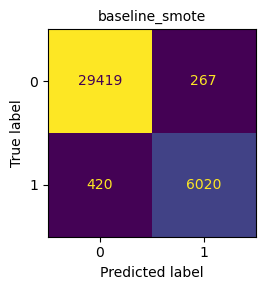

2026/04/12 13:29:55 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:29:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


'              precision    recall  f1-score   support\n\n           0       0.99      0.99      0.99     29686\n           1       0.96      0.93      0.95      6440\n\n    accuracy                           0.98     36126\n   macro avg       0.97      0.96      0.97     36126\nweighted avg       0.98      0.98      0.98     36126\n'

In [14]:
print("testing after applying smote")
(baseline("baseline_smote", X_smote, y_smote, X_val, y_val))


### Under and over sampling increases recall for y=1 (trending videos) and improves f1 score for class 1
### This is the important metric for our business case
## Smote gives highest recall and f1 score for y=1 so will be used as balancing strategy

# 1: gaussian naive bayes model 

In [15]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.naive_bayes import GaussianNB

Best Params: {'var_smoothing': 1e-07}, Best CV Score: 0.9242
Confusion Matrix: TN=28776, FP=910, FN=819, TP=5621
  
Grid Search for Gaussian NB
  accuracy: 0.9521
  f1: 0.9188
  precision: 0.8607
  recall: 0.8728
  roc_auc: 0.9580
  Wasted_Resources_False_Positive: 0.1393
  Missed_Trending_Videos: 0.1272

              precision    recall  f1-score   support

           0       0.97      0.97      0.97     29686
           1       0.86      0.87      0.87      6440

    accuracy                           0.95     36126
   macro avg       0.92      0.92      0.92     36126
weighted avg       0.95      0.95      0.95     36126



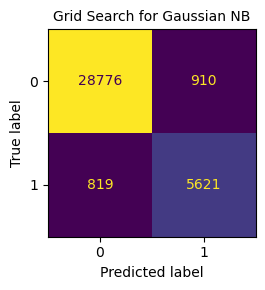

2026/04/12 13:30:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:30:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


({'accuracy': 0.9521397331561756,
  'f1': 0.9187682348504124,
  'precision': 0.8606645230439443,
  'recall': 0.8728260869565218,
  'roc_auc': 0.9579533982599657,
  'Wasted_Resources_False_Positive': np.float64(0.13933547695605572),
  'Missed_Trending_Videos': np.float64(0.12717391304347825)},
 GridSearchCV(cv=5, estimator=GaussianNB(),
              param_grid={'var_smoothing': [1e-11, 1e-10, 1e-09, 1e-08, 1e-07,
                                            1e-06, 1e-05, 0.0001, 0.001]},
              scoring='f1_macro'))

In [ ]:
gnb = GaussianNB()
param_grid = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]
}
search = GridSearchCV(
    estimator=gnb,
    param_grid=param_grid,
    cv=5,  # Use 5 fold on training set
    scoring='f1_macro',
)
run_experiment("Grid Search for Gaussian NB", search, X_smote, y_smote, X_val, y_val)


# 2: KNN Model

In [18]:
from sklearn.neighbors import KNeighborsClassifier

Best Params: {'algorithm': 'auto', 'n_neighbors': 3, 'weights': 'distance'}, Best CV Score: 0.9814
Confusion Matrix: TN=28642, FP=1044, FN=373, TP=6067
  
Grid Search for KNN
  accuracy: 0.9608
  f1: 0.9356
  precision: 0.8532
  recall: 0.9421
  roc_auc: 0.9697
  Wasted_Resources_False_Positive: 0.1468
  Missed_Trending_Videos: 0.0579

              precision    recall  f1-score   support

           0       0.99      0.96      0.98     29686
           1       0.85      0.94      0.90      6440

    accuracy                           0.96     36126
   macro avg       0.92      0.95      0.94     36126
weighted avg       0.96      0.96      0.96     36126



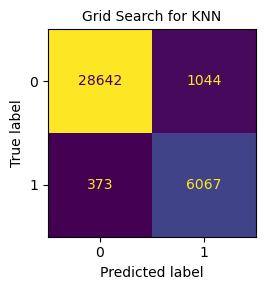

2026/04/12 13:50:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 13:50:19 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


({'accuracy': 0.9607761722858883,
  'f1': 0.9356463946545884,
  'precision': 0.8531852060188441,
  'recall': 0.9420807453416149,
  'roc_auc': 0.9696516029263643,
  'Wasted_Resources_False_Positive': np.float64(0.14681479398115596),
  'Missed_Trending_Videos': np.float64(0.05791925465838509)},
 GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
              param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                          'n_neighbors': [3, 5, 7, 9, 11],
                          'weights': ['uniform', 'distance']},
              scoring='f1_macro'))

In [ ]:
knn = KNeighborsClassifier()
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}
search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,  # Use 5 fold on training set
    scoring='f1_macro',
)
run_experiment("Grid Search for KNN", search, X_smote, y_smote, X_val, y_val)

# 3: ADA Model

In [21]:
from sklearn.ensemble import AdaBoostClassifier

Best Params: {'n_estimators': 200, 'learning_rate': 1.0}, Best CV Score: 0.9570
Confusion Matrix: TN=28793, FP=893, FN=416, TP=6024
  
Randomized Search for AdaBoost
  accuracy: 0.9638
  f1: 0.9399
  precision: 0.8709
  recall: 0.9354
  roc_auc: 0.9917
  Wasted_Resources_False_Positive: 0.1291
  Missed_Trending_Videos: 0.0646

              precision    recall  f1-score   support

           0       0.99      0.97      0.98     29686
           1       0.87      0.94      0.90      6440

    accuracy                           0.96     36126
   macro avg       0.93      0.95      0.94     36126
weighted avg       0.97      0.96      0.96     36126



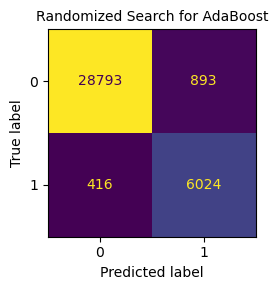

2026/04/12 14:34:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 14:34:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


({'accuracy': 0.9637657089077118,
  'f1': 0.9398864782224388,
  'precision': 0.8708977880584068,
  'recall': 0.9354037267080745,
  'roc_auc': 0.991677667767352,
  'Wasted_Resources_False_Positive': np.float64(0.1291022119415932),
  'Missed_Trending_Videos': np.float64(0.06459627329192547)},
 RandomizedSearchCV(cv=5, estimator=AdaBoostClassifier(), n_iter=15,
                    param_distributions={'learning_rate': [0.01, 0.05, 0.1, 0.5,
                                                           0.7, 1.0],
                                         'n_estimators': [10, 50, 80, 100, 200]},
                    scoring='f1_macro'))

In [ ]:
ada = AdaBoostClassifier()
param_grid = {
    'n_estimators': [10, 50, 80, 100, 200],
    'learning_rate': [0.01, 0.05, 0.1, 0.5, 0.7, 1.0]
}
search = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_grid,
    cv=5,  # Use 5 fold on training set
    scoring='f1_macro',
    n_iter=15
)
run_experiment("Randomized Search for AdaBoost", search, X_smote, y_smote, X_val, y_val)

In [31]:
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

Best Params: {'C': 0.1, 'penalty': 'l2'}, Best CV Score: 0.9231
Confusion Matrix: TN=28274, FP=1412, FN=703, TP=5737
  
Grid Search for LinearSVC with squared_hinge loss
  accuracy: 0.9415
  f1: 0.9042
  precision: 0.8025
  recall: 0.8908
  Wasted_Resources_False_Positive: 0.1975
  Missed_Trending_Videos: 0.1092

              precision    recall  f1-score   support

           0       0.98      0.95      0.96     29686
           1       0.80      0.89      0.84      6440

    accuracy                           0.94     36126
   macro avg       0.89      0.92      0.90     36126
weighted avg       0.94      0.94      0.94     36126



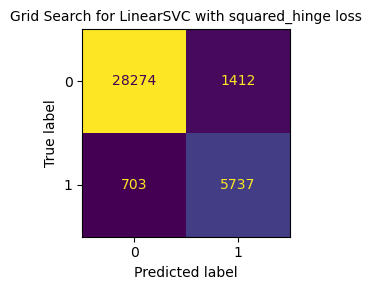

2026/04/12 15:34:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 15:34:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


({'accuracy': 0.9414549078226209,
  'f1': 0.9041530093222461,
  'precision': 0.8024898587214995,
  'recall': 0.8908385093167702,
  'roc_auc': None,
  'Wasted_Resources_False_Positive': np.float64(0.1975101412785005),
  'Missed_Trending_Videos': np.float64(0.10916149068322982)},
 GridSearchCV(cv=5, estimator=LinearSVC(),
              param_grid={'C': [0.1, 1, 10], 'penalty': ['l1', 'l2']},
              scoring='f1_macro'))

In [34]:
svm_linear = LinearSVC(loss='squared_hinge')
param_grid = {
    'penalty' : ['l1','l2'],
    'C': [0.1, 1, 10]
    
}
search = GridSearchCV(
    estimator=svm_linear,
    param_grid=param_grid,
    cv=5,  # Use 5 fold on training set
    scoring='f1_macro',
)
run_experiment("Grid Search for LinearSVC with squared_hinge loss", search, X_smote, y_smote, X_val, y_val)